##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip install keras-cv

Loaded: 5 images
OK files:
- /kaggle/input/datasets/layan1234layan/lab4-image/aeroplane.jpg
- /kaggle/input/datasets/layan1234layan/lab4-image/bicycle.jpg
- /kaggle/input/datasets/layan1234layan/lab4-image/boat.jpg
- /kaggle/input/datasets/layan1234layan/lab4-image/sheep.jpg
- /kaggle/input/datasets/layan1234layan/lab4-image/sofa.webp


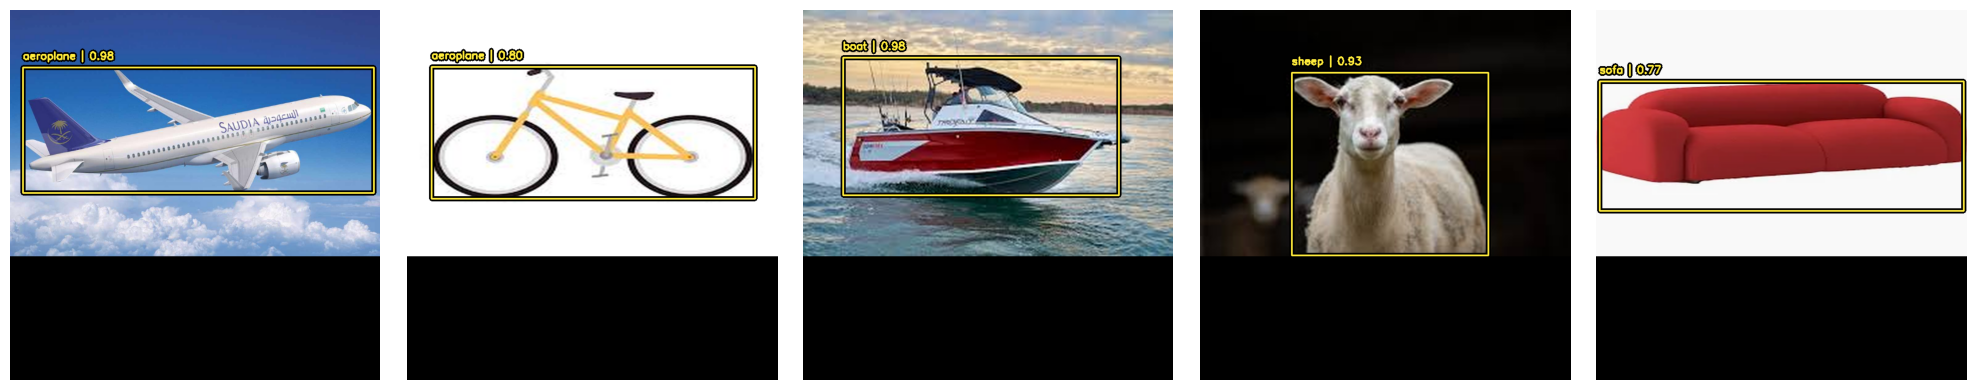

In [3]:
import numpy as np
import tensorflow as tf
import keras_cv
from PIL import Image
import os

VOC_CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

# Load YOLOv8 Pascal VOC preset
detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)


def load_image(path: str, size=(900, 600)) -> np.ndarray:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found")

    img = Image.open(path).convert("RGB")   # works with all formats
    img = img.resize(size, Image.Resampling.LANCZOS)
    return np.array(img)


image_paths = [
   "/kaggle/input/datasets/layan1234layan/lab4-image/aeroplane.jpg",
   "/kaggle/input/datasets/layan1234layan/lab4-image/bicycle.jpg",
   "/kaggle/input/datasets/layan1234layan/lab4-image/boat.jpg",
   "/kaggle/input/datasets/layan1234layan/lab4-image/sheep.jpg",
   "/kaggle/input/datasets/layan1234layan/lab4-image/sofa.webp"
]

images_list = []
good_paths = []

for p in image_paths:
    try:
        arr = load_image(p, size=(900, 600))
        images_list.append(arr)
        good_paths.append(p)
    except Exception as e:
        print(f"[SKIP] {p} -> {type(e).__name__}: {e}")

if len(images_list) < 1:
    raise RuntimeError("No images loaded. Check your file paths.")

images_np = np.stack(images_list, axis=0)

print("Loaded:", len(images_list), "images")
print("OK files:", *good_paths, sep="\n- ")

# Resize 
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

images_resized = inference_resizing(tf.convert_to_tensor(images_np))

# Predict
predictions = detector.predict(images_resized, verbose=0)

# Visualize detections
keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0, 255),
    y_pred=predictions,
    bounding_box_format="xywh",
    class_mapping=dict(enumerate(VOC_CLASS_NAMES)),
    rows=1,
    cols=min(5, len(images_list)),
    scale=4,
    font_scale=0.6,
    show=True,
)